# 沐曦 GPU 运行 Merlin 说明文档

[Merlin](https://github.com/StanfordMIMI/Merlin) 是 Stanford MIMI 发布的三维 CT 表征与医学推理模型。本 Notebook 在沐曦 GPU 上直接调用 Merlin Python 接口，依次复现跨模态图像-文本嵌入、单独图像嵌入、表型预测、五年疾病预测，以及两种按解剖系统生成放射学报告的能力。一次完整运行默认执行全部六项任务，并将每项任务的实际输出写入 Notebook。

[Merlin](https://github.com/StanfordMIMI/Merlin) 由第三方以 [MIT License](https://github.com/StanfordMIMI/Merlin/blob/main/LICENSE) 发布，我方未对其源代码作任何修改。您可通过上述链接查阅该项目的源代码、许可证全文、版权与归属声明及其他声明文件。

输入必须是调用者拥有使用权的三维 CT NIfTI 文件（`.nii` 或 `.nii.gz`）。Merlin 的预处理会将 CT 转换到 RAS 方向，重采样到 `(1.5, 1.5, 3)` 间距，使用 HU 窗口 `[-1000, 1000]` 做强度缩放，并填充/中心裁剪到 `(224, 224, 160)`。输入预览、预处理张量、模型推理和结果展示均在同一执行流程中完成，不依赖本 Notebook 之外的辅助脚本。

模型输出仅用于开源软件适配、工程和研究验证，不代表诊断、预后、治疗建议或临床准确性。


## 1. 安装

### 1.1 沐曦容器

使用包含 MACA 版 PyTorch 的沐曦镜像启动容器，并将 Merlin 源码、模型资产和本 Notebook 所在目录挂载到容器内。下面的命令只用于说明环境准备方式，不会由 Notebook 自动执行。

```bash
docker run -it --name merlin-maca \
  --device=/dev/mxcd --group-add video \
  --shm-size=16G --security-opt seccomp=unconfined \
  --ulimit memlock=-1 --ulimit stack=67108864 \
  -v /path/to/Merlin:/opt/Merlin \
  -v /path/to/merlin-assets:/workspace/merlin-assets \
  -v /path/to/MedicalImage/vlm/merlin:/workspace/tutorial \
  <MACA_PYTORCH_IMAGE> /bin/bash
```

其中 `--device=/dev/mxcd` 用于挂载沐曦 GPU，`--group-add video` 提供设备访问权限，`--shm-size` 为三维 CT 预处理和模型加载提供共享内存。

### 1.2 安装 Merlin 与 Notebook 依赖

在容器中准备 Merlin 源码和运行依赖；MACA 版 PyTorch 与 torchvision 使用容器提供的实现。模型权重、医学图像和患者数据不随本教程提供。

```bash
cd /opt/Merlin
python -m pip install -r requirements.txt
python -m pip install -e .
python -m pip install nibabel matplotlib jupyterlab sentencepiece peft nltk
```

报告任务还需要 RadLLaMA-7b 和相关文本模型资产。运行前请确认模型、文本模型和输入数据的上游许可、隐私处理及使用权限。


## 2. 沐曦 GPU 运行效果展示

本节从同一输入和同一份预处理张量出发，依次执行六个独立推理单元。每个单元只负责一个任务；模型完成后释放显存，避免同时驻留多个大型检查点。

| 任务 | 结果 |
| --- | --- |
| `default` | 图像嵌入、EHR 嵌入和文本嵌入；使用文本提示 |
| `image_embedding` | 图像嵌入 |
| `phenotype` | 表型预测输出向量 |
| `five_year` | 五年疾病预测输出向量 |
| `report` | 13 个解剖系统的放射学报告 |
| `report_stage1` | 另一报告生成阶段组合的 13 个解剖系统报告 |

输出包含设备信息、预处理张量、向量统计和报告文本，均来自本次 Notebook 执行。

### 2.1 运行参数

以下参数是后续单元的共享锚点。Notebook 固定按顺序执行六个任务单元，所有单元复用同一个输入和预处理张量。


In [1]:
import json
import os
from pathlib import Path

extra_site_packages = os.environ.get("MERLIN_EXTRA_SITE_PACKAGES", "").strip()
if extra_site_packages:
    import sys
    sys.path.insert(0, extra_site_packages)

MODEL_NAME = "StanfordMIMI/Merlin"
TASKS = {
    "default": "cross-modal image/text embedding",
    "image_embedding": "image embedding",
    "phenotype": "phenotype prediction",
    "five_year": "five-year disease prediction",
    "report": "radiology report generation",
    "report_stage1": "stage-one/stage-two report generation",
}
TASKS_TO_RUN = tuple(TASKS)

MERLIN_SOURCE_DIR = Path(os.environ.get("MERLIN_SOURCE_DIR", "/opt/Merlin")).expanduser()
ASSET_ROOT = Path(os.environ.get("MERLIN_ASSET_ROOT", "/workspace/merlin-assets")).expanduser()
WORK_DIR = Path(os.environ.get("MERLIN_WORK_DIR", "/workspace/merlin_demo")).expanduser()
INPUT_PATH = Path(
    os.environ.get("MERLIN_INPUT_PATH", str(ASSET_ROOT / "sample-data/image1.nii.gz"))
).expanduser()
OUTPUT_DIR = Path(os.environ.get("MERLIN_OUTPUT_DIR", str(WORK_DIR / "outputs"))).expanduser()
CACHE_DIR = Path(os.environ.get("MERLIN_CACHE_DIR", str(WORK_DIR / "preprocess_cache"))).expanduser()
TEXT_PROMPT = os.environ.get(
    "MERLIN_TEXT_PROMPT",
    "Describe the findings represented by this CT volume.",
)
MAX_NEW_TOKENS = int(os.environ.get("MERLIN_MAX_NEW_TOKENS", "128"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_CHECKPOINT_NAMES = {
    "default": "i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt",
    "image_embedding": "i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt",
    "phenotype": "i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt",
    "five_year": "resnet_clinical_longformer_five_year_disease_prediction.pt",
    "report": "resnet_gpt2_best_stanford_report_generation_average_mtl.pt",
    "report_stage1": "resnet_gpt2_best_stanford_report_generation_average.pt",
}
ASSET_CHECKPOINT_DIR = ASSET_ROOT / "models/checkpoints"
MERLIN_CHECKPOINT_DIR = MERLIN_SOURCE_DIR / "merlin/models/checkpoints"
MERLIN_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def link_asset(source, target):
    target = Path(target)
    if not target.exists():
        target.symlink_to(source)

for checkpoint_name in dict.fromkeys(MODEL_CHECKPOINT_NAMES.values()):
    link_asset(
        ASSET_CHECKPOINT_DIR / checkpoint_name,
        MERLIN_CHECKPOINT_DIR / checkpoint_name,
    )

REPORT_CACHE_DIR = ASSET_ROOT / "models/llm-cache"
REPORT_CACHE_LINK = MERLIN_SOURCE_DIR / "checkpoints"
if not REPORT_CACHE_LINK.exists():
    REPORT_CACHE_LINK.symlink_to(REPORT_CACHE_DIR, target_is_directory=True)

os.environ.setdefault("HF_HUB_CACHE", str(ASSET_ROOT / "hf/transformers"))
os.environ.setdefault("HF_HUB_OFFLINE", "1")
os.environ.setdefault("HF_HOME", str(ASSET_ROOT / "hf"))
os.environ.setdefault("TRANSFORMERS_CACHE", str(ASSET_ROOT / "hf/transformers"))
os.environ.setdefault("HF_MODULES_CACHE", str(ASSET_ROOT / "hf/modules"))
os.environ.setdefault("TORCH_HOME", str(ASSET_ROOT / "torch"))
os.chdir(MERLIN_SOURCE_DIR)

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch

DEVICE = torch.device("cuda:0")
print("PyTorch version:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))
print("Model:", MODEL_NAME)
print("Merlin source:", MERLIN_SOURCE_DIR)
print("Input:", INPUT_PATH)
print("Tasks:", " -> ".join(TASKS_TO_RUN))
print("Output directory:", OUTPUT_DIR)
print("Preprocess cache:", CACHE_DIR)

PyTorch version: 2.6.0+metax3.8.0.7
GPU: MetaX C500
Model: StanfordMIMI/Merlin
Merlin source: /opt/Merlin
Input: /workspace/merlin-assets/sample-data/image1.nii.gz
Tasks: default -> image_embedding -> phenotype -> five_year -> report -> report_stage1
Output directory: /workspace/merlin_demo/outputs
Preprocess cache: /workspace/merlin_demo/preprocess_cache


### 2.2 输入准备与预览

预览使用的文件与后续 `DataLoader` 和模型实际消费的文件是同一个路径。Notebook 不下载样例医学图像，也不将患者数据写入仓库。


Input shape (i, j, k): (512, 512, 489)
Input spacing:           (0.9766, 0.9766, 1.0)
Preview slice:            244 along k axis
Voxel range:              (-1024.0, 3071.0)
Affine:
 [[  -0.9765625     0.            0.          249.51171875]
 [  -0.            0.9765625     0.          -90.51171875]
 [   0.           -0.            1.         -547.79998779]
 [   0.            0.            0.            1.        ]]


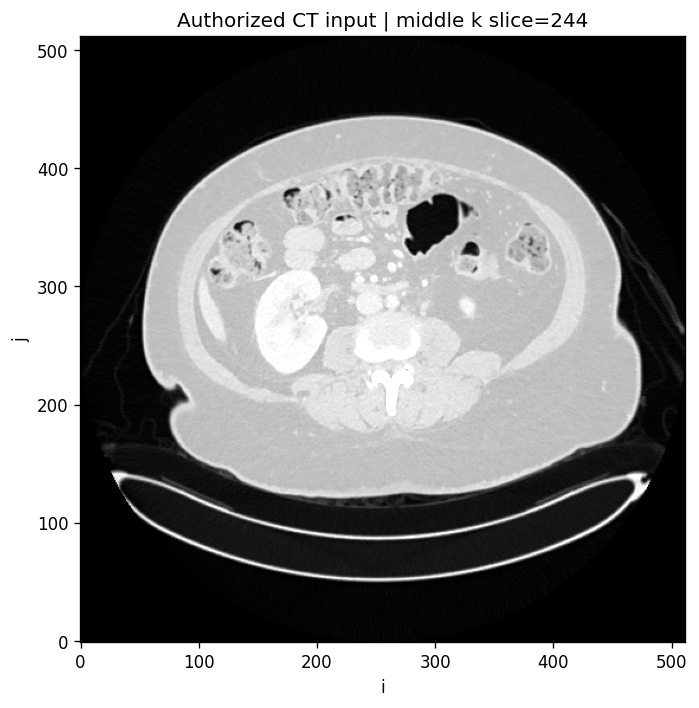

In [2]:
if not INPUT_PATH.is_file():
    raise FileNotFoundError(
        f"找不到输入 NIfTI：{INPUT_PATH}。请设置 MERLIN_INPUT_PATH，并确认数据已获授权。"
    )
nifti = nib.load(str(INPUT_PATH))
volume = np.asanyarray(nifti.dataobj)
spacing = tuple(float(value) for value in nifti.header.get_zooms()[:3])
slice_index = volume.shape[2] // 2
slice_image = volume[:, :, slice_index]
low, high = np.percentile(slice_image, (1, 99))

print("Input shape (i, j, k):", tuple(int(value) for value in volume.shape))
print("Input spacing:          ", tuple(round(value, 4) for value in spacing))
print("Preview slice:           ", slice_index, "along k axis")
print("Voxel range:             ", (float(volume.min()), float(volume.max())))
print("Affine:\n", np.asarray(nifti.affine, dtype=float))

figure, axis = plt.subplots(figsize=(7, 6))
axis.imshow(slice_image.T, cmap="gray", origin="lower", vmin=low, vmax=high)
axis.set_title(f"Authorized CT input | middle k slice={slice_index}")
axis.set_xlabel("i")
axis.set_ylabel("j")
plt.tight_layout()
plt.show()


### 2.3 加载模型与预处理

这里直接使用 Merlin 的 `Merlin` 和 `DataLoader` 接口。三维 CT 只预处理一次，后续六项任务复用同一个 `model_input`；模型则按任务逐个加载。


In [3]:
import sys
if str(MERLIN_SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(MERLIN_SOURCE_DIR))

import re
import types


download_module = types.ModuleType("merlin.data.download_data")
def download_sample_data(*args, **kwargs):
    raise RuntimeError("本 Notebook 使用已准备的本地医学图像，不执行在线下载。")
download_module.download_sample_data = download_sample_data
sys.modules["merlin.data.download_data"] = download_module


utils_module = types.ModuleType("merlin.utils")
def download_file(*args, **kwargs):
    raise RuntimeError("本 Notebook 使用已准备的本地模型资产，不执行在线下载。")
utils_module.download_file = download_file
sys.modules["merlin.utils"] = utils_module

import torch.nn as nn


try:
    import peft
except ModuleNotFoundError:
    peft_compat = types.ModuleType("peft")

    class LoraConfig:
        def __init__(self, lora_alpha, lora_dropout, r, bias, task_type):
            self.lora_alpha = lora_alpha
            self.lora_dropout = lora_dropout
            self.r = r

    class LoraLinear(nn.Module):
        def __init__(self, base_layer, config):
            super().__init__()
            self.base_layer = base_layer
            self.lora_dropout = nn.ModuleDict({"default": nn.Dropout(config.lora_dropout)})
            self.lora_A = nn.ModuleDict({
                "default": nn.Linear(base_layer.in_features, config.r, bias=False)
            })
            self.lora_B = nn.ModuleDict({
                "default": nn.Linear(config.r, base_layer.out_features, bias=False)
            })
            self.scaling = config.lora_alpha / config.r

        def forward(self, inputs):
            output = self.base_layer(inputs)
            update = self.lora_B["default"](
                self.lora_A["default"](self.lora_dropout["default"](inputs))
            )
            return output + update * self.scaling

    class BaseModel(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, *args, **kwargs):
            return self.model(*args, **kwargs)

        def generate(self, *args, **kwargs):
            return self.model.generate(*args, **kwargs)

    class PeftModel(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.base_model = BaseModel(model)

        @property
        def device(self):
            return next(self.parameters()).device

        @property
        def model(self):
            return self.base_model.model

        def forward(self, *args, **kwargs):
            return self.base_model.model(*args, **kwargs)

        def generate(self, *args, **kwargs):
            return self.base_model.model.generate(*args, **kwargs)

        def print_trainable_parameters(self):
            trainable = sum(parameter.numel() for parameter in self.parameters() if parameter.requires_grad)
            total = sum(parameter.numel() for parameter in self.parameters())
            print(f"trainable params: {trainable:,} || all params: {total:,}")

    def get_peft_model(model, config):
        for layer in model.model.layers:
            for name in ("q_proj", "v_proj"):
                current = getattr(layer.self_attn, name)
                setattr(layer.self_attn, name, LoraLinear(current, config))
        return PeftModel(model)

    peft_compat.__spec__ = __import__("importlib.machinery").machinery.ModuleSpec("peft", loader=None)
    peft_compat.LoraConfig = LoraConfig
    peft_compat.PeftModel = PeftModel
    peft_compat.get_peft_model = get_peft_model
    sys.modules["peft"] = peft_compat


try:
    from nltk.tokenize import wordpunct_tokenize
except ModuleNotFoundError:
    nltk_module = types.ModuleType("nltk")
    tokenize_module = types.ModuleType("nltk.tokenize")

    def wordpunct_tokenize(text):
        return re.findall(r"\w+|[^\w\s]", text, flags=re.UNICODE)

    tokenize_module.wordpunct_tokenize = wordpunct_tokenize
    nltk_module.tokenize = tokenize_module
    sys.modules["nltk"] = nltk_module
    sys.modules["nltk.tokenize"] = tokenize_module


from merlin import Merlin
from merlin.data.dataloaders import DataLoader

batch = next(iter(DataLoader(
    [{"image": str(INPUT_PATH), "text": ""}],
    cache_dir=str(CACHE_DIR),
    batchsize=1,
    shuffle=False,
)))
model_input = batch["image"].to(DEVICE)

print("Preprocessed tensor shape:", tuple(model_input.shape))
print("Preprocessed tensor dtype:", model_input.dtype)
print("Preprocessed tensor device:", model_input.device)
print("Preprocessed range:", (float(model_input.min()), float(model_input.max())))

Size of dataset: 1

Preprocessed tensor shape: (1, 1, 224, 224, 160)
Preprocessed tensor dtype: torch.float32
Preprocessed tensor device: cuda:0
Preprocessed range: (0.0, 1.0)


### 2.4 推理任务共享逻辑

下面只提供结果转换和展示工具；每个任务单元都直接加载对应模型、执行推理、保存 JSON 并释放显存。

In [4]:
import gc
from transformers import StoppingCriteria

SYSTEMS = (
    "lower thorax", "liver", "gallbladder", "spleen", "pancreas",
    "adrenal glands", "kidneys", "bowel", "peritoneum", "pelvic",
    "circulatory", "lymph nodes", "musculoskeletal",
)
EOS_TOKEN_ID = 48134


class EosListStoppingCriteria(StoppingCriteria):
    def __call__(self, input_ids, scores, **kwargs):
        return EOS_TOKEN_ID in input_ids[:, -1].tolist()


def tensor_output(raw_output):
    values = raw_output if isinstance(raw_output, (tuple, list)) else (raw_output,)
    tensors = [value.detach().float().cpu() for value in values]
    return {
        "shapes": [list(value.shape) for value in tensors],
        "vectors": [value.flatten().tolist() for value in tensors],
    }


def save_task_result(task, description, output):
    result = {
        "model": MODEL_NAME,
        "task": task,
        "description": description,
        "input": str(INPUT_PATH),
        "input_shape": list(volume.shape),
        "preprocessed_shape": list(model_input.shape),
        "precision": str(model_input.dtype).replace("torch.", ""),
        "output": output,
    }
    result_path = OUTPUT_DIR / f"merlin-{task}.json"
    result_path.write_text(json.dumps(result, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    print("Saved result:", result_path)
    return result


VECTOR_NAMES = {
    "default": ["image_embedding", "ehr_embedding", "text_embedding"],
    "image_embedding": ["image_embedding"],
    "phenotype": ["phenotype_output"],
    "five_year": ["five_year_output"],
}


def display_task_result(task, result):
    print(f"\n[{task}] {result['description']}")
    print("Input shape:", result["input_shape"], "Preprocessed shape:", result["preprocessed_shape"])
    output = result["output"]
    if "vectors" in output:
        for name, vector, shape in zip(
            VECTOR_NAMES[task], output["vectors"], output["shapes"]
        ):
            array = np.asarray(vector, dtype=float)
            print(
                f"{name}: shape={shape}, min={array.min():.6g}, "
                f"max={array.max():.6g}, norm={np.linalg.norm(array):.6g}"
            )
        values = np.asarray(output["vectors"][0], dtype=float)[:32]
        _, axis = plt.subplots(figsize=(11, 3))
        axis.bar(np.arange(len(values)), values)
        axis.set_title(f"Merlin {task} output (first {len(values)} values)")
        axis.set_xlabel("output index")
        axis.set_ylabel("raw value")
        plt.tight_layout()
        plt.show()
    else:
        print("Reports returned:", len(output["reports"]))
        for system, report in output["reports"].items():
            print(f"\n## {system}\n{report}")

### 2.4.1 `default`

本单元只执行 `default` 推理并保存该任务的 JSON 结果。



===== default: cross-modal image/text embedding =====
Loading checkpoint for 'default' task from /opt/Merlin/merlin/models/checkpoints/i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt
Saved result: /workspace/merlin_demo/outputs/merlin-default.json

[default] cross-modal image/text embedding
Input shape: [512, 512, 489] Preprocessed shape: [1, 1, 224, 224, 160]
image_embedding: shape=[1, 512], min=-0.104255, max=0.126063, norm=1
ehr_embedding: shape=[1, 1692], min=-18.5099, max=2.21597, norm=310.082
text_embedding: shape=[1, 512], min=-0.126575, max=0.143046, norm=1


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Loading weights: 100%|##########| 269/269 [00:00<00:00, 35509.15it/s]
/opt/conda/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve 

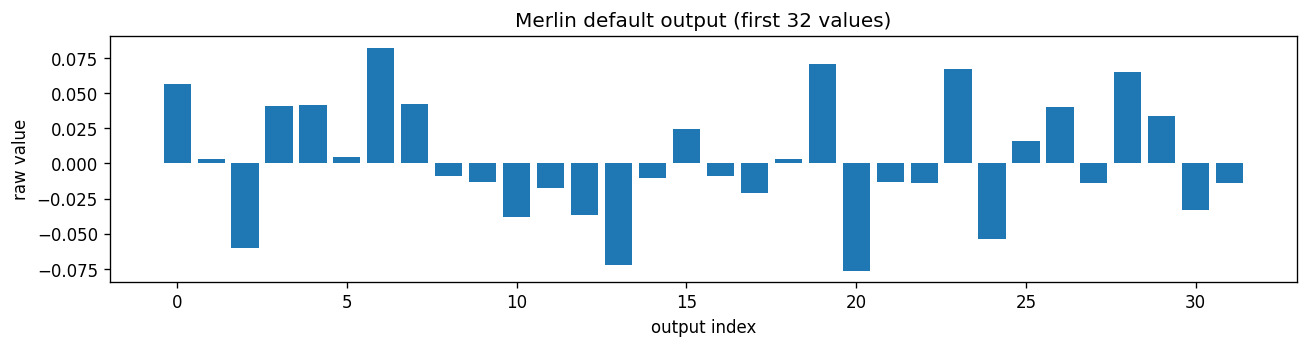

In [5]:
print("\n===== default: cross-modal image/text embedding =====")
torch.cuda.empty_cache()
model = Merlin().eval().to(DEVICE)
with torch.inference_mode():
    output = tensor_output(model(model_input, [TEXT_PROMPT]))
default_result = save_task_result("default", "cross-modal image/text embedding", output)
display_task_result("default", default_result)
del model
gc.collect()
torch.cuda.empty_cache()

### 2.4.2 `image_embedding`

本单元只执行 `image_embedding` 推理并保存该任务的 JSON 结果。



===== image_embedding: image embedding =====
Loading checkpoint for 'default' task from /opt/Merlin/merlin/models/checkpoints/i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt
Saved result: /workspace/merlin_demo/outputs/merlin-image_embedding.json

[image_embedding] image embedding
Input shape: [512, 512, 489] Preprocessed shape: [1, 1, 224, 224, 160]
image_embedding: shape=[1, 1, 2048], min=0.0390747, max=1.6782, norm=21.3663


Loading weights: 100%|##########| 269/269 [00:00<00:00, 25230.17it/s]


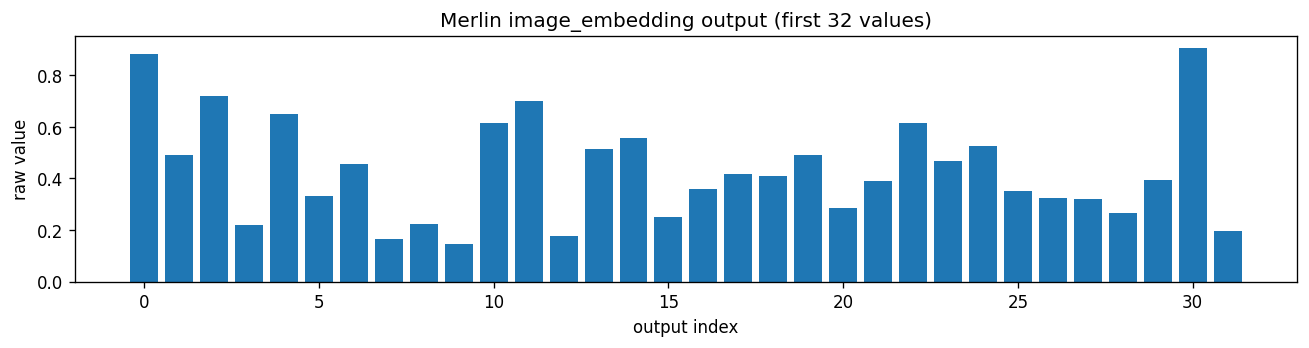

In [6]:
print("\n===== image_embedding: image embedding =====")
torch.cuda.empty_cache()
model = Merlin(ImageEmbedding=True).eval().to(DEVICE)
with torch.inference_mode():
    output = tensor_output(model(model_input))
image_embedding_result = save_task_result("image_embedding", "image embedding", output)
display_task_result("image_embedding", image_embedding_result)
del model
gc.collect()
torch.cuda.empty_cache()

### 2.4.3 `phenotype`

本单元只执行 `phenotype` 推理并保存该任务的 JSON 结果。



===== phenotype: phenotype prediction =====
Loading checkpoint for 'default' task from /opt/Merlin/merlin/models/checkpoints/i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt
Saved result: /workspace/merlin_demo/outputs/merlin-phenotype.json

[phenotype] phenotype prediction
Input shape: [512, 512, 489] Preprocessed shape: [1, 1, 224, 224, 160]
phenotype_output: shape=[1, 1692], min=9.15608e-09, max=0.90169, norm=1.83259


Loading weights: 100%|##########| 269/269 [00:00<00:00, 28780.87it/s]


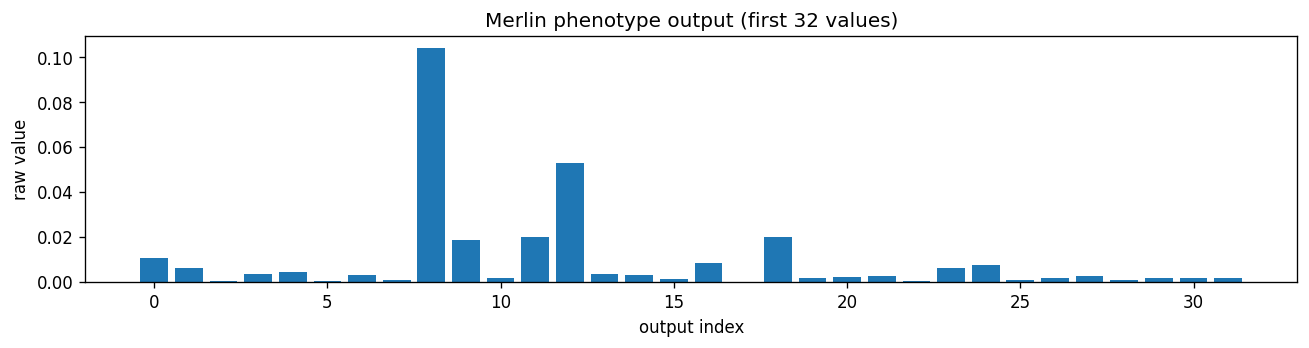

In [7]:
print("\n===== phenotype: phenotype prediction =====")
torch.cuda.empty_cache()
model = Merlin(PhenotypeCls=True).eval().to(DEVICE)
with torch.inference_mode():
    output = tensor_output(model(model_input))
phenotype_result = save_task_result("phenotype", "phenotype prediction", output)
display_task_result("phenotype", phenotype_result)
del model
gc.collect()
torch.cuda.empty_cache()

### 2.4.4 `five_year`

本单元只执行 `five_year` 推理并保存该任务的 JSON 结果。



===== five_year: five-year disease prediction =====
Loading checkpoint for 'five_year_disease_prediction' task from /opt/Merlin/merlin/models/checkpoints/resnet_clinical_longformer_five_year_disease_prediction.pt
Saved result: /workspace/merlin_demo/outputs/merlin-five_year.json

[five_year] five-year disease prediction
Input shape: [512, 512, 489] Preprocessed shape: [1, 1, 224, 224, 160]
five_year_output: shape=[1, 6], min=0.283048, max=0.532776, norm=0.953899


Loading weights: 100%|##########| 269/269 [00:00<00:00, 28588.35it/s]


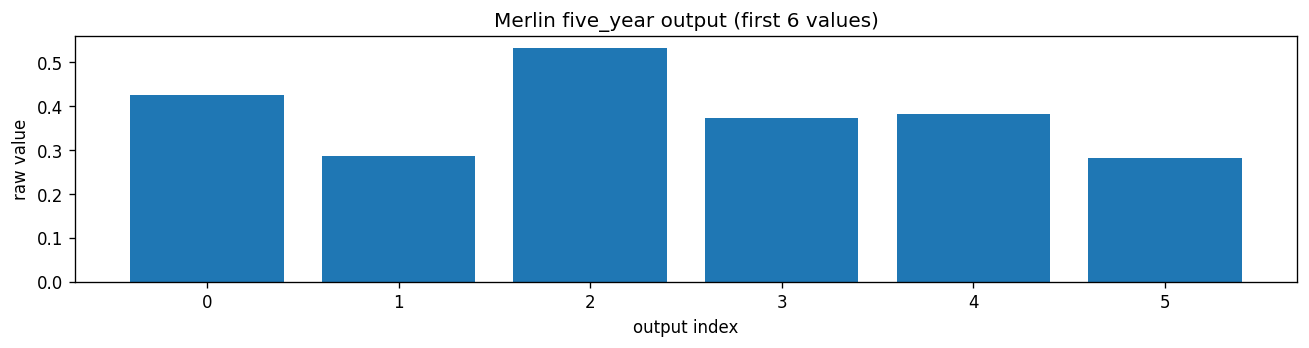

In [8]:
print("\n===== five_year: five-year disease prediction =====")
torch.cuda.empty_cache()
model = Merlin(FiveYearPred=True).eval().to(DEVICE)
with torch.inference_mode():
    output = tensor_output(model(model_input))
five_year_result = save_task_result("five_year", "five-year disease prediction", output)
display_task_result("five_year", five_year_result)
del model
gc.collect()
torch.cuda.empty_cache()

### 2.4.5 `report`

本单元只执行 `report` 推理并保存该任务的 JSON 结果。


In [9]:
print("\n===== report: radiology report generation =====")
torch.cuda.empty_cache()
model = Merlin(RadiologyReport=True).eval().to(DEVICE)
with torch.inference_mode():
    reports = {}
    for system in SYSTEMS:
        generated = model.generate(
            model_input,
            [f"Generate a radiology report for {system}###\n"],
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.2,
            max_new_tokens=MAX_NEW_TOKENS,
            stopping_criteria=[EosListStoppingCriteria()],
        )
        reports[system] = generated[0].split("###")[0].strip()
report_result = save_task_result("report", "radiology report generation", {"reports": reports})
display_task_result("report", report_result)
del model
gc.collect()
torch.cuda.empty_cache()


===== report: radiology report generation =====
trainable params: 268,435,456 || all params: 7,006,851,072 || trainable%: 3.831042692953643
Loading checkpoint for 'report_generation' task from /opt/Merlin/merlin/models/checkpoints/resnet_gpt2_best_stanford_report_generation_average_mtl.pt
Saved result: /workspace/merlin_demo/outputs/merlin-report.json

[report] radiology report generation
Input shape: [512, 512, 489] Preprocessed shape: [1, 1, 224, 224, 160]
Reports returned: 13

## lower thorax
lower thorax: normal.

## liver
liver and biliary tree: normal.

## gallbladder
gallbladder: normal.

## spleen
spleen: normal.

## pancreas
pancreas: normal.

## adrenal glands
adrenal glands: normal.

## kidneys
kidneys and ureters: normal.

## bowel
gastrointestinal tract: normal.

## peritoneum
peritoneal cavity: no free fluid. abdominal wall: normal.

## pelvic
bladder: normal. uterus and ovaries: the uterus is surgically absent. no adnexal masses are seen.

## circulatory
vasculature: pa

Loading weights: 100%|##########| 291/291 [00:00<00:00, 5662.80it/s]
/opt/conda/lib/python3.10/site-packages/transformers/generation/utils.py:1119: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torch/_tensor.py:1648: UserWarning: 1Torch was not compiled with memory efficient attention. (Triggered internally at /workspace/framework/mcPytorch/aten/src/ATen/native/transformers/cuda/sdp_utils.cpp:692.)
  ret = func(*args, **kwargs)


### 2.4.6 `report_stage1`

本单元只执行 `report_stage1` 推理并保存该任务的 JSON 结果。


In [10]:
print("\n===== report_stage1: stage-one/stage-two report generation =====")
torch.cuda.empty_cache()
model = Merlin(RadiologyReportStage1_Stage2=True).eval().to(DEVICE)
with torch.inference_mode():
    reports = {}
    for system in SYSTEMS:
        generated = model.generate(
            model_input,
            [f"Generate a radiology report for {system}###\n"],
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.2,
            max_new_tokens=MAX_NEW_TOKENS,
            stopping_criteria=[EosListStoppingCriteria()],
        )
        reports[system] = generated[0].split("###")[0].strip()
report_stage1_result = save_task_result("report_stage1", "stage-one/stage-two report generation", {"reports": reports})
display_task_result("report_stage1", report_stage1_result)
del model
gc.collect()
torch.cuda.empty_cache()


===== report_stage1: stage-one/stage-two report generation =====
trainable params: 268,435,456 || all params: 7,006,851,072 || trainable%: 3.831042692953643
Loading checkpoint for 'report_generation_stage1_stage2' task from /opt/Merlin/merlin/models/checkpoints/resnet_gpt2_best_stanford_report_generation_average.pt
Saved result: /workspace/merlin_demo/outputs/merlin-report_stage1.json

[report_stage1] stage-one/stage-two report generation
Input shape: [512, 512, 489] Preprocessed shape: [1, 1, 224, 224, 160]
Reports returned: 13

## lower thorax
lower thorax: normal.

## liver
liver and biliary tree: normal.

## gallbladder
gallbladder: normal.

## spleen
spleen: normal.

## pancreas
pancreas: normal.

## adrenal glands
adrenal glands: normal.

## kidneys
kidneys and ureters: normal.

## bowel
gastrointestinal tract: no evidence of bowel obstruction. normal appendix (3/297).

## peritoneum
peritoneal cavity: no free fluid. abdominal wall: normal.

## pelvic
bladder: normal. uterus and

Loading weights: 100%|##########| 291/291 [00:00<00:00, 6577.51it/s]


## 许可证、数据与安全说明

- Merlin 运行时源码以 [MIT License](https://github.com/StanfordMIMI/Merlin/blob/main/LICENSE) 发布；相关 MONAI 运行时以 [Apache-2.0](https://github.com/Project-MONAI/MONAI/blob/dev/LICENSE) 发布。
- `report` 和 `report_stage1` 使用 [RadLLaMA-7b](https://huggingface.co/StanfordAIMI/RadLLaMA-7b)，须遵守 Llama 2 Community License；[Clinical-Longformer](https://huggingface.co/yikuan8/Clinical-Longformer) 的公开模型卡未声明许可证，分发前须由使用者完成授权确认。
- 本教程不包含模型权重、医学输入或患者数据。使用者必须自行确认 NIfTI 数据来源、隐私处理、使用权以及输出再分发条件。
- 结果仅用于工程/研究验证，不用于诊断、治疗、临床决策、患者服务或监管提交。

本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。

Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.
